In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

load data

In [2]:
tsla = pd.read_csv(
    "../data/processed/TSLA.csv",
    index_col=0,
    parse_dates=True
)

spy = pd.read_csv(
    "../data/processed/SPY.csv",
    index_col=0,
    parse_dates=True
)

bnd = pd.read_csv(
    "../data/processed/BND.csv",
    index_col=0,
    parse_dates=True
)

create price dataframe

In [3]:
prices = pd.DataFrame({
    "TSLA": tsla["Close"],
    "SPY": spy["Close"],
    "BND": bnd["Close"]
})

prices.head()

,TSLA,SPY,BND
Date,,,
2015-01-02,14.620667,205.429993,82.650002
2015-01-05,14.006000,201.720001,82.889999
2015-01-06,14.085333,199.820007,83.129997
2015-01-07,14.063333,202.309998,83.180000
2015-01-08,14.041333,205.899994,83.050003


calculate daily return

In [4]:
returns = prices.pct_change().dropna()

returns.head()

,TSLA,SPY,BND
Date,,,
2015-01-05,-0.042041,-0.018060,0.002904
2015-01-06,0.005664,-0.009419,0.002895
2015-01-07,-0.001562,0.012461,0.000602
2015-01-08,-0.001564,0.017745,-0.001563
2015-01-09,-0.018802,-0.008014,0.001686


backtesting period

In [5]:
backtest_returns = returns.loc["2025-01-01":"2026-01-01"]

backtest_returns.head()

,TSLA,SPY,BND
Date,,,
2025-01-02,-0.060816,-0.002457,0.000417
2025-01-03,0.082156,0.012503,-0.001251
2025-01-06,0.001486,0.005761,-0.000974
2025-01-07,-0.040603,-0.011304,-0.003483
2025-01-08,0.001471,0.001461,0.001118


stratery portfolio

In [6]:
strategy_weights = np.array([
    0.0,   # TSLA
    1.0,   # SPY
    0.0    # BND
])

bench mark portfolio

In [7]:
benchmark_weights = np.array([
    0.0,
    0.60,
    0.40
])

daily portfolio return

In [8]:
strategy_returns = backtest_returns.dot(strategy_weights)

benchmark_returns = backtest_returns.dot(benchmark_weights)

cumulative returns

In [9]:
strategy_cumulative = (1 + strategy_returns).cumprod()

benchmark_cumulative = (1 + benchmark_returns).cumprod()

plot performance

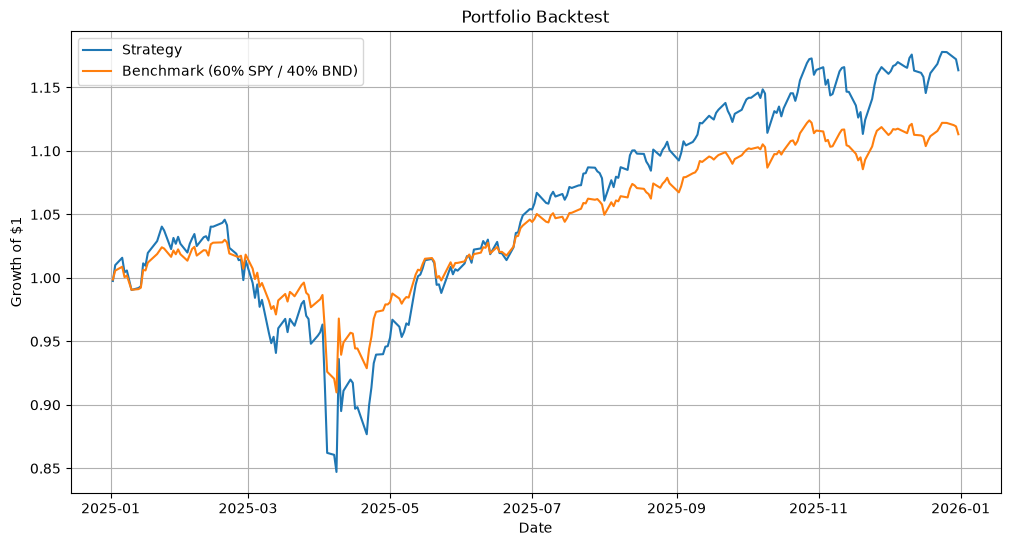

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    strategy_cumulative,
    label="Strategy"
)

plt.plot(
    benchmark_cumulative,
    label="Benchmark (60% SPY / 40% BND)"
)

plt.title("Portfolio Backtest")

plt.xlabel("Date")

plt.ylabel("Growth of $1")

plt.legend()

plt.grid(True)

plt.show()

performance function

In [11]:
def annual_return(r):
    return (1 + r.mean())**252 - 1


def annual_volatility(r):
    return r.std() * np.sqrt(252)


def sharpe_ratio(r, rf=0.02):
    ar = annual_return(r)
    av = annual_volatility(r)
    return (ar - rf) / av


def max_drawdown(cumulative):
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown.min()

strategy metrix

In [12]:
strategy_metrics = {
    "Total Return":
        strategy_cumulative.iloc[-1]-1,

    "Annual Return":
        annual_return(strategy_returns),

    "Sharpe Ratio":
        sharpe_ratio(strategy_returns),

    "Maximum Drawdown":
        max_drawdown(strategy_cumulative)
}

strategy_metrics

{'Total Return': np.float64(0.16352710043963037),
 'Annual Return': np.float64(0.18690099621702538),
 'Sharpe Ratio': np.float64(0.856700722073942),
 'Maximum Drawdown': np.float64(-0.18998904129504934)}

benchmark metrix

In [13]:
benchmark_metrics = {
    "Total Return":
        benchmark_cumulative.iloc[-1]-1,

    "Annual Return":
        annual_return(benchmark_returns),

    "Sharpe Ratio":
        sharpe_ratio(benchmark_returns),

    "Maximum Drawdown":
        max_drawdown(benchmark_cumulative)
}

benchmark_metrics

{'Total Return': np.float64(0.1131365549377692),
 'Annual Return': np.float64(0.12205816744222964),
 'Sharpe Ratio': np.float64(0.8498975006110089),
 'Maximum Drawdown': np.float64(-0.11670688352347436)}

comparision table

In [14]:
comparison = pd.DataFrame({
    "Strategy": strategy_metrics,
    "Benchmark": benchmark_metrics
})

comparison

,Strategy,Benchmark
Total Return,0.163527,0.113137
Annual Return,0.186901,0.122058
Sharpe Ratio,0.856701,0.849898
Maximum Drawdown,-0.189989,-0.116707
